In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Problem 1

- [Part 1: k-means assumptions](#Part-1:-k-means-assumptions)
- [Part 2: Identifying regions of interest](#Part-2:-Identifying-regions-of-interest)

## Part 1: k-means assumptions

The k-means algorithm makes the assumption that clusters are convex and isotropic, which is not always the case. It responds poorly to elongated clusters, clusters with irregular shapes or unevenly sized clusters.

Your goal is to use k-means to cluster the following four datasets.
The examples are meant to illustrate situations where k-means produces unintuitive and possibly unexpected clusters.

In [11]:
# put your distance and k-means functions here
def distance(X,Y):
    m,n = X.shape
    p,q = Y.shape
    
    return -2*X.dot(Y.T) + np.sum(X**2,axis=1).reshape(m,1) + np.sum(Y**2,axis=1).reshape(1,p)

In [12]:
def kmeans(X,k):
    
    it = 0
    
    max_iterations = 1000
    repeat = True
    
    m,n = X.shape
    
    centers = X[np.random.choice(m,k)]
    dist = distance(X,centers)
    clusters = np.argmin(dist, axis = 1)
    
    while repeat and it<max_iterations:
        centers = np.array([np.mean(X[clusters==i], axis=0) 
        if np.sum(clusters==i)!=0
        else  X[np.random.choice(m,1)]                          
        for i in range(k)])
        
        dist = distance(X,centers)
        new_clusters = np.argmin(dist, axis=1)
        
        if np.sum(clusters!=new_clusters)==0:
            repeat = False
        clusters = new_clusters
        
        it += 1
        
    return clusters, centers

**Example 1:** Three elongated clusters

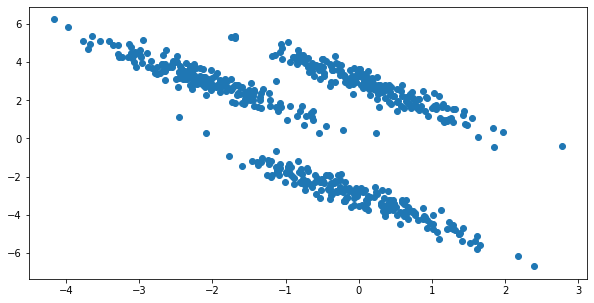

In [25]:
# three-elongated-blobs dataset

X = np.zeros([600,2])
transformation = np.array([[0.60834549, -0.63667341], [-0.40887718, 0.85253229]])

X[0:200] = np.random.randn(200,2) + [-2,2]
X[200:400] = np.random.randn(200,2) + [5,7]
X[400:600] = np.random.randn(200,2) + [-5,-7]

X = X.dot(transformation)
plt.figure(figsize=(10,5))
plt.scatter(X[:,0],X[:,1])

In [26]:
# use kmeans with k = 3 
k = 3
clusters, centers = kmeans(X,k)

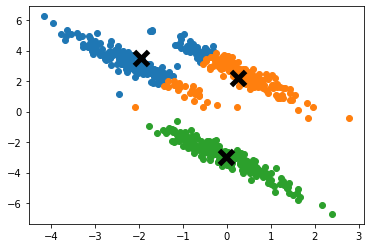

In [27]:
# plot the three clusters
# plot dataset plt.scatter(X[:,0],X[:,1]) 
# plot centers 
for i in range(k):
    plt.scatter(X[clusters==i,0],X[clusters==i,1])
    plt.scatter(centers[i,0],centers[i,1],marker = 'x',color='k', s=200, linewidths=5)

**Example 2:** two-moons dataset.

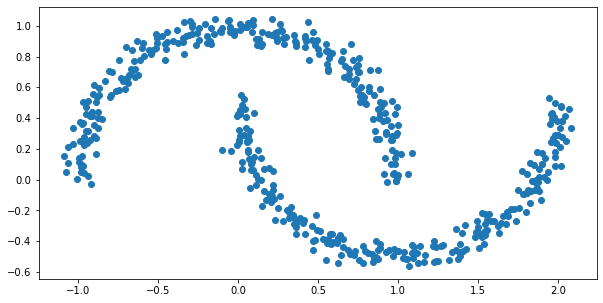

In [28]:
from sklearn.datasets import make_moons
X,y = make_moons(n_samples=500,noise=0.05)

plt.figure(figsize=(10,5))
plt.scatter(X[:,0],X[:,1])

In [29]:
# use kmeans with k = 2
k = 2
clusters, centers = kmeans (X,k)

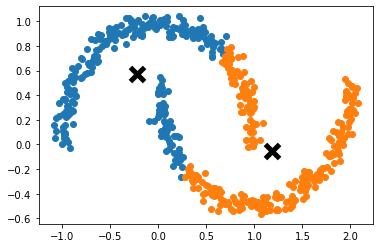

In [30]:
# plot the two clusters
for i in range(k):
    plt.scatter(X[clusters==i,0],X[clusters==i,1])
    plt.scatter(centers[i,0],centers[i,1],marker = 'x',color='k', s=200, linewidths=5)

**Example 3:** two-circles dataset

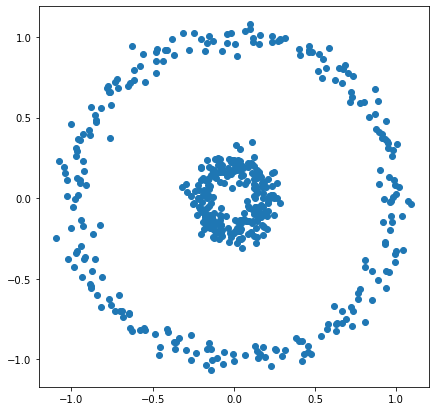

In [31]:
from sklearn.datasets import make_circles
X,y = make_circles(n_samples=500,noise=0.05, factor=0.2)


plt.figure(figsize=(7,7))
plt.scatter(X[:,0],X[:,1])

In [32]:
# use kmeans with k = 2
k = 2
clusters, centers = kmeans (X,k)

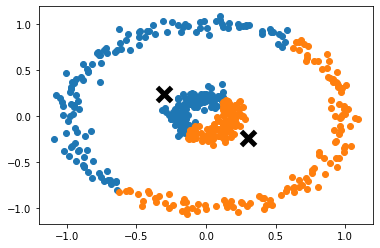

In [33]:
# plot the two clusters
for i in range(k):
    plt.scatter(X[clusters==i,0],X[clusters==i,1])
    plt.scatter(centers[i,0],centers[i,1],marker = 'x',color='k', s=200, linewidths=5)

**Example 4:** three unevenly sized clusters

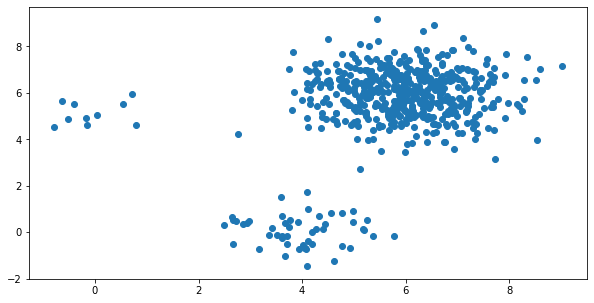

In [39]:
X = np.zeros((560,2)) 
X[0:500] = np.random.randn(500,2) + [6,6] # blob 1 (big)
X[500:550] = 0.7*np.random.randn(50,2) + [4,0] # blob 2 (medium)
X[550:560] = 0.5*np.random.randn(10,2) + [0,5] # blob 3 (small)

plt.figure(figsize=(10,5))
plt.scatter(X[:,0],X[:,1])

In [40]:
# use kmeans with k = 3
k = 3
clusters, centers = kmeans (X,k)

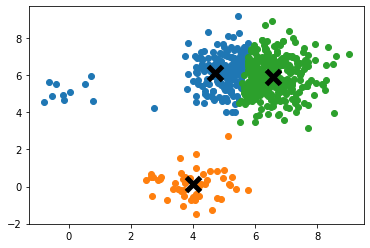

In [41]:
# plot the three clusters
for i in range(k):
    plt.scatter(X[clusters==i,0],X[clusters==i,1])
    plt.scatter(centers[i,0],centers[i,1],marker = 'x',color='k', s=200, linewidths=5)

## Part 2: Identifying regions of interest

Color segmentation can be used to identify regions of interest and objects in an image.

(-0.5, 191.5, 119.5, -0.5)

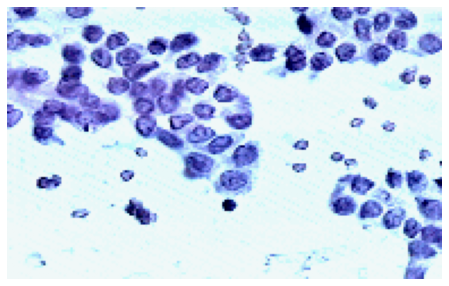

In [42]:
# load the image
from matplotlib.image import imread
url = 'https://raw.githubusercontent.com/um-perez-alvaro/Data-Science-Theory/master/Data/cancer_cells.png'
image = imread(url)[:,:,0:3]

# display the image
plt.figure(figsize=(10,5))
plt.imshow(image)
plt.axis('off')

`cancer_cells.png` is a digital image of a small section of a breast cancer mass.

In [43]:
# reshape it as a tall matrix
X = image.reshape(-1,3)
X.shape

(23040, 3)

Here, you'll use k-means to isolate the cells from the background.

**First**, cluster the pixels (i.e., the rows of X) using the k-means algorithm with k=2.

In [44]:
# your code here
k=2
clusters, centers = kmeans(X,k)

**Second**, color each pixel in cluster 0 in white [1,1,1], and each pixel in cluster 1 in black [0,0,0]. 

In [47]:
X_segmented = np.empty(X.shape) 
for i in range(k):
    if i == 0:
        X_segmented[clusters==i] = [1,1,1]
    else:
        X_segmented[clusters==i] = [0,0,0]
    image_segmented = X_segmented.reshape(image.shape)

**Finally**, plot the resulting image.

(-0.5, 191.5, 119.5, -0.5)

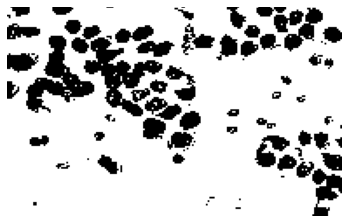

In [49]:
# your code here
plt.imshow(image_segmented)
plt.axis(False)